# Air Passengers Forecasting using ARIMA and SARIMA MODELS

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, Seaborn, and SKLearn libraries.
- Our primary focus will be on key operations commonly used in these libraries for building "TIME SERIES" models.
- The following operations will be conducted on the CSV file:

   - Importing the necessary libraries.
   - Loading the dataset for the experiment.
   - Understanding the data contained in the file.
   - Performing data cleaning.
   - Preparing the data for further processing within the Data Science Life Cycle.
   - Conducting Exploratory Data Analysis (EDA) on the processed data.
   - Building predictive models using the EDA-processed data.
   - Performing model evaluations.

**Experiment Link** --> https://colab.research.google.com/drive/10sIuCJx3JXs6QR5TcRvrJeGPEATc84GZ?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1wI6eKwp_kw6WwbtCvKOlRl-xSRXgfmWI/view?usp=sharing



### STEP 1. Problem statement:-
- We want to perform some time series forecasting operations on the AirPassengers dataset for predicting the future incoming customer flow to arrange the planes for a smooth experience without any losses.

### STEP 2.Importing the necessary libraries.


In [ ]:
# Import Libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 3.Loading the Dataset into the Environment.


In [ ]:
# Loading the dataset.
data = pd.read_csv("/content/AirPassengers.csv")
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


### STEP 4.Data Cleaning Operation performed on the dataset.


In [ ]:
# we need to convert the month col as object to a datetime column.
data['Month'] = pd.to_datetime(data['Month'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [ ]:
# checking for null values.
data.isnull().sum()

,0
Month,0
#Passengers,0


In [ ]:
# Check for duplicate values.
data.duplicated().sum()

np.int64(0)

In [ ]:
data.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [ ]:
# changing our month col as index.
data.set_index("Month",inplace = True)

### STEP 5.Exploratory Data Analysis(EDA) & Feature Engineering.


<Axes: xlabel='Month'>

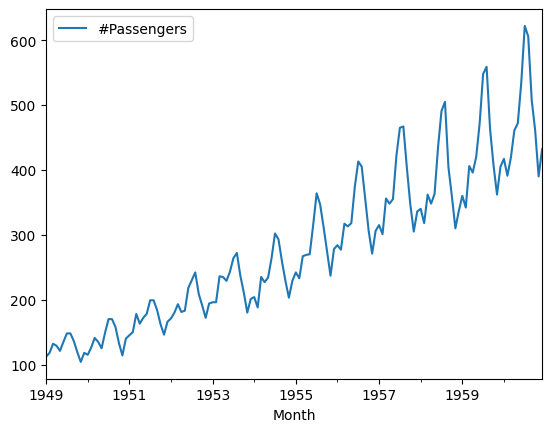

In [ ]:
data.plot()

- Seasonality -In this graph, we have more seasonality. To reduce this, we perform some seasonal decomposition techniques.

### P1 - Seasonal Decomposition
- seasonal decompose - take your time series data as input and decompose into 3 main components.
1. Trend -- the overall direction or pattern in the data over a long period of time.
2. seasonality - the repeating short-term cycle in the data(monthly/quarterly).
3. residual/noise - unpredictable change.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

Figure(640x480)


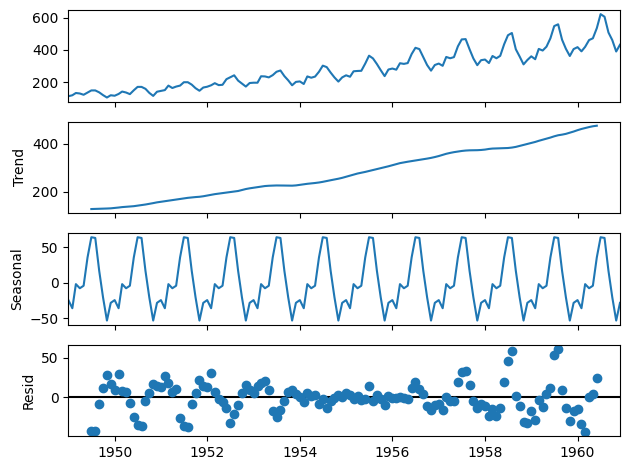

In [ ]:
decomposed = seasonal_decompose(data)
print(decomposed.plot())

- By observing this graph we find that we have Trend, Seasonality and Noise in the graph. We want to reduce it.

### P2 - Applying ADF to the data.


- Check whether the data is stationary or not?
1. ADF - Augmented Dickey-Fuller test

2. null hypo - data is not stationary
3. alt hypo- data is station

4. if p-val less than 0.05 --- data is stationary -- acc the null
5. if p-vall >0.05 -- data is not stationa --- acc the alt

In [ ]:
from statsmodels.tsa.stattools import adfuller
test_result = adfuller(data)

In [ ]:
test_result
print("ADF Statistics:",test_result[0])
print("p_Value",test_result[1])
print("Critical Value",test_result[4])

ADF Statistics: 0.8153688792060498
p_Value 0.991880243437641
Critical Value {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


In [ ]:
if test_result[1] < 0.05:
  print("reject the null hypo ---- data is statio")
else:
  print("------data is not stationary---")

------data is not stationary---


- Stationary - The data that has a constant mean and variance.
- Asvour data - We need to convert our data into stationary.
- For that, we need to stabilise the mean and variance over time.

- remove seasonality
- removing trend

### P3 - Log function.
- We converted the data into a stationary state.

<Axes: xlabel='Month'>

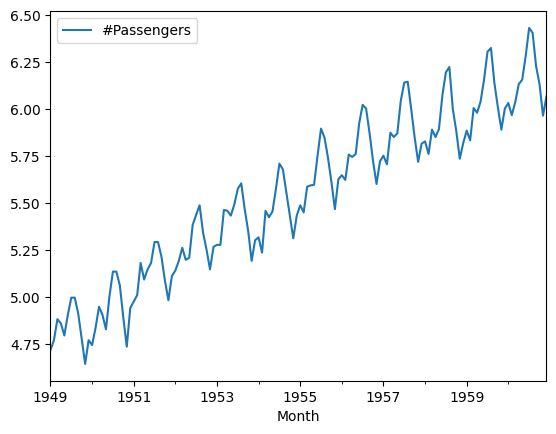

In [ ]:
#logrithmic transformation
first_log = np.log(data)
first_log = first_log.dropna()
first_log.plot()

In [ ]:
first_log.head()

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791


### P4 - Applying the rolling function on the mean and the standard deviation.

- rolling mean(mean_log) - this computes the moving average of the timeseries over a specific window
- It helps us to smooth out short-term fluctuations and highlight the long-term trends
- rolling std(std_log)--- moving std -- how much variation exist around the rolling mean

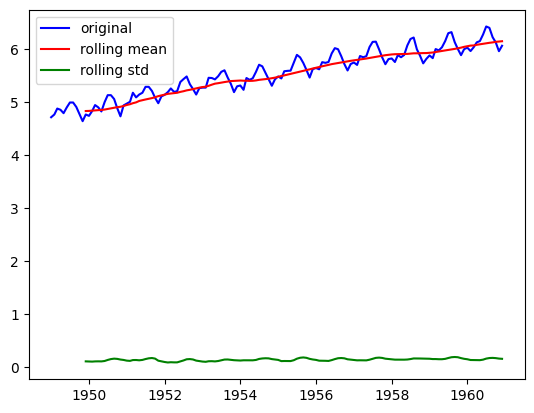

In [ ]:
mean_log = first_log.rolling(window = 12).mean()
std_log = first_log.rolling(window = 12).std()
plt.plot(first_log,color = 'blue',label = 'original')
plt.plot(mean_log,color = 'red',label = 'rolling mean')
plt.plot(std_log,color = 'green',label = 'rolling std')
plt.legend(loc = 'best')



In [ ]:
mean_log.head(20)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


In [ ]:
# checking for null values.
mean_log.isnull().sum().sum()

np.int64(11)

In [ ]:
# We are removing the null values from the dataset.
new_data = first_log - mean_log
new_data = new_data.dropna()
new_data.head(10)

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
1950-05-01,-0.027529
1950-06-01,0.139881
1950-07-01,0.260184
1950-08-01,0.248635


<Axes: xlabel='Month'>

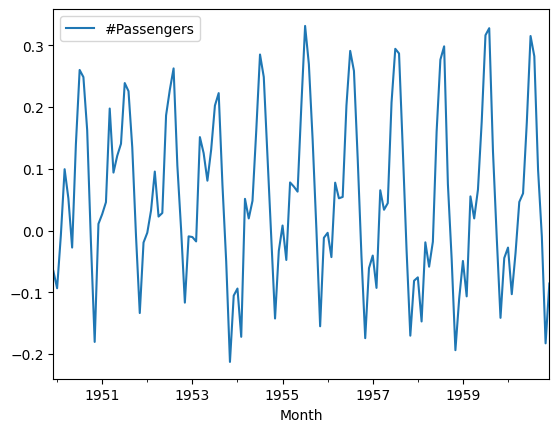

In [ ]:
new_data.plot()

- Now the data is set down in the minimum range values.

In [ ]:
# Again checking whether the data is stationary or not.
test_result = adfuller(new_data)

In [ ]:
test_result
print("ADF Statistics:",test_result[0])
print("p_Value",test_result[1])
print("Critical Value",test_result[4])

ADF Statistics: -3.1629079913008833
p_Value 0.022234630001242206
Critical Value {'1%': np.float64(-3.4865346059036564), '5%': np.float64(-2.8861509858476264), '10%': np.float64(-2.579896092790057)}


- Now the P-value is 0.05.

In [ ]:
if test_result[1] < 0.05:
  print("Reject the null hypo ---- data is stationary")
else:
  print("------data is not stationary---")

Reject the null hypo ---- data is stationary


- Now we are satisfied with this transformed data.

In [ ]:
new_data.head()

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142


### STEP 6. Divide the dataset into Train and Test data.

In [ ]:
train = new_data.iloc[:120]['#Passengers']
test = new_data.iloc[120:]['#Passengers']

In [ ]:
train.shape

(120,)

In [ ]:
test.shape

(13,)

### STEP 7.Model Selection & Training: Choose algorithms based on problem type.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import *

In [ ]:
import itertools
p = range (0,7)
d = range(1,2)
q = range(0,7)

pdq = list(itertools.product(p,d,q))
rmse = []
order1 = []
for i in pdq:
  model = ARIMA(train,order = i)
  model_fit = model.fit()
  pred = model_fit.predict(start = len(train), end = len(train)+len(test)-1)  #start = 120, ending = 120+13 = 133 #0-132
  error = np.sqrt(mean_squared_error(test,pred))
  order1.append(i)
  rmse.append(error)

results =pd.DataFrame(index = order1,data = rmse,columns = ['RMSE'])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
results.sort_values(by = 'RMSE',ascending = True).head()

,RMSE
"(6, 1, 6)",0.066423
"(4, 1, 6)",0.073258
"(5, 1, 6)",0.076548
"(6, 1, 1)",0.099005
"(4, 1, 5)",0.109957


###IMPLEMENT ARIMA
- Autoregressive integrated moving average
- P, D, Q
- p - order of lag
- d - degree of differencing
-  q - order of moving average

In [ ]:
A_model = ARIMA(train,order=(6,1,6))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
# Train the model.
A_model = A_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Predicting the values with test data.
new_data['Arima_Prediction'] = A_model.predict(start = len(train), end = len(train)+len(test)-1)

### STEP 8: Model Evaluation  


<Axes: xlabel='Month'>

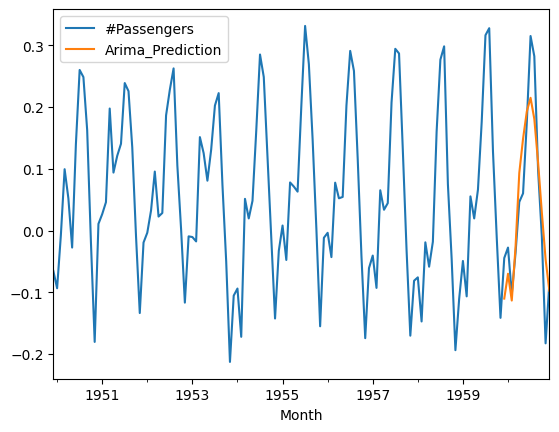

In [ ]:
new_data[['#Passengers',"Arima_Prediction"]].plot()

### STEP 7.Model Selection & Training: Choose algorithms based on problem type.


### IMPLEMENT SARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train the model.
model = SARIMAX(train,order =(6,1,6), seasonal_order= (6,1,6,12))
model = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Predicting the values with test data.
new_data['Sarima_Prediction'] = model.predict(start = len(train), end = len(train)+len(test)-1)

### STEP 8: Model Evaluation  


<Axes: xlabel='Month'>

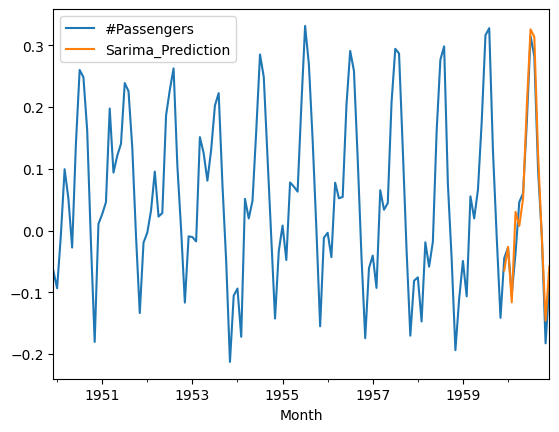

In [ ]:
new_data[['#Passengers',"Sarima_Prediction"]].plot()

- Comparing both models with visualising the predictions, the "SARIMAX model" projects the accurate line along with the original data.

- Forecasting the 5 years passengers flow using the SARIMAX model.

<Axes: xlabel='Month'>

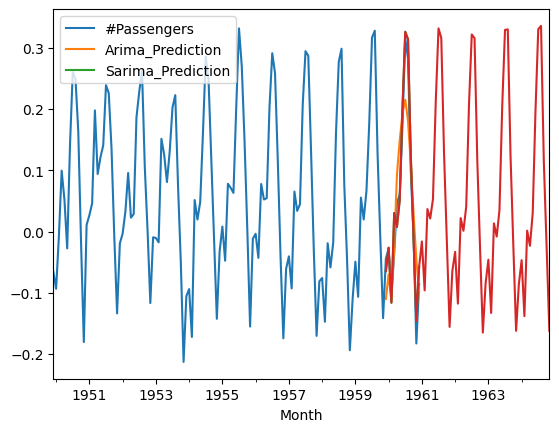

In [ ]:
# lets forecast for 5 years 5*12 = 60 months
future = model.forecast(steps = 60)
new_data.plot()
future.plot()